In [ ]:
from google.colab import files
uploaded = files.upload()


Saving data.csv to data.csv


In [ ]:
import pandas as pd

# Example: load CSV file
df = pd.read_csv("data.csv")  # replace with your dataset path

# Rename columns if needed
df = df.rename(columns={"Sentence": "text", "Sentiment": "sent"})

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

pipe = pipeline("text-classification", model=model, tokenizer=tokenizer, framework="pt")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
def get_finbert_sentiment(text):
    # FinBERT has a max token limit, truncate if needed
    result = pipe(text[:512])
    label = result[0]['label'].lower()
    score = result[0]['score']
    return label, score


In [ ]:
df[['pred_sentiment', 'sentiment_score']] = df['text'].apply(
    lambda x: pd.Series(get_finbert_sentiment(x))
)


In [ ]:
print(df[['text', 'sent', 'pred_sentiment', 'sentiment_score']].head())

# Optional: simple accuracy
accuracy = (df['sent'] == df['pred_sentiment']).mean()
print(f"Accuracy: {accuracy:.2%}")


                                                text      sent pred_sentiment  \
0  The GeoSolutions technology will leverage Bene...  positive       positive   
1  $ESI on lows, down $1.50 to $2.50 BK a real po...  negative       negative   
2  For the last quarter of 2010 , Componenta 's n...  positive       positive   
3  According to the Finnish-Russian Chamber of Co...   neutral        neutral   
4  The Swedish buyout firm has sold its remaining...   neutral        neutral   

   sentiment_score  
0         0.674475  
1         0.967869  
2         0.948198  
3         0.947906  
4         0.937019  
Accuracy: 75.81%


              precision    recall  f1-score   support

    negative       0.51      0.82      0.63       860
     neutral       0.82      0.75      0.78      3130
    positive       0.87      0.75      0.80      1852

    accuracy                           0.76      5842
   macro avg       0.73      0.77      0.74      5842
weighted avg       0.79      0.76      0.77      5842

Confusion Matrix:
 [[ 709  124   27]
 [ 610 2333  187]
 [  73  392 1387]]


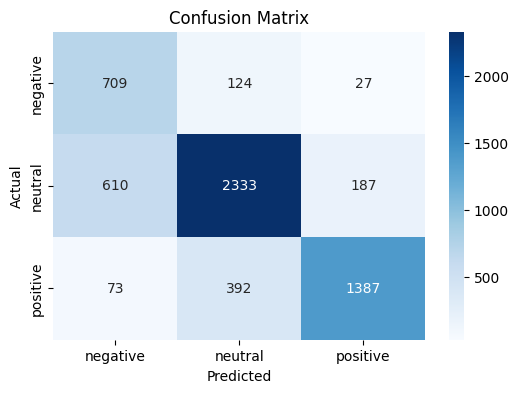

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Assuming your true labels are in df['sent']
# And predicted labels in df['pred_sentiment']

print(classification_report(df['sent'], df['pred_sentiment']))

cm = confusion_matrix(df['sent'], df['pred_sentiment'])
print("Confusion Matrix:\n", cm)
import seaborn as sns
import matplotlib.pyplot as plt

labels = sorted(df['sent'].unique())  # or ['positive', 'neutral', 'negative']

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
